# Spotify Music Recommendation System
## Notebook 05 — Content-Based Recommender

**Purpose:** Use cosine similarity on the 14-dimensional feature vector to recommend the most musically similar songs for any given track.

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Load Model Payload](#2-load-model-payload)
3. [What is Cosine Similarity?](#3-what-is-cosine-similarity)
4. [The Recommender](#4-the-recommender)
5. [Test the Recommender](#5-test-the-recommender)
6. [Similarity Score Analysis](#6-similarity-score-analysis)
7. [Save the Model](#7-save-the-model)
8. [Summary](#8-summary)

## 1. Setup & Imports

In [10]:
import sys
import warnings
warnings.filterwarnings('ignore')

import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Make src/ importable from notebooks/
sys.path.insert(0, str(Path('..').resolve()))

from src.data.load import load_feature_matrix, load_feature_columns, load_recommender_payload
from src.models.recommender import ContentBasedRecommender

DATA_DIR  = Path('../data/processed')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print('src modules loaded.')

src modules loaded.


## 2. Load Model Payload

In [11]:
# If the payload already exists, load from pickle (fast).
# Otherwise, load from CSVs (after running notebook 04).
payload_path = MODEL_DIR / 'recommender_payload.pkl'

if payload_path.exists():
    payload = load_recommender_payload()
    feature_matrix  = payload['feature_matrix']
    track_index     = payload['track_index']
    feature_columns = payload['feature_columns']
    print('Loaded from saved payload (models/recommender_payload.pkl)')
else:
    feature_matrix_df, track_index = load_feature_matrix()
    feature_columns = load_feature_columns()
    feature_matrix  = feature_matrix_df.values
    print('Loaded from CSVs')

print(f'Feature matrix : {feature_matrix.shape}  (rows=tracks, cols=features)')
print(f'Track index    : {track_index.shape}')
print(f'Features used  : {feature_columns}')
track_index.head(3)

Loaded from saved payload (models/recommender_payload.pkl)
Feature matrix : (169040, 14)  (rows=tracks, cols=features)
Track index    : (169040, 5)
Features used  : ['valence', 'acousticness', 'danceability', 'energy', 'loudness', 'log_instrumentalness', 'log_speechiness', 'log_liveness', 'tempo_norm', 'key_sin', 'key_cos', 'mode', 'explicit_int', 'popularity_norm']


,id,name,artists,year,popularity
0,4BJqT0PrAfrxzMOxytFOIz,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...","Sergei Rachmaninoff, James Levine, Berliner Ph...",1921,4
1,7xPhfUan2yNtyFG0cUWkt8,Clancy Lowered the Boom,Dennis Day,1921,5
2,1o6I8BglA6ylDMrIELygv1,Gati Bali,KHP Kridhamardawa Karaton Ngayogyakarta Hadini...,1921,5


## 3. What is Cosine Similarity?

Each track is represented as a 14-dimensional vector of normalised audio features.

Cosine similarity measures the **angle** between two vectors:
- **1.0** = same direction = very similar audio profile
- **0.0** = perpendicular = nothing in common

To recommend songs for a given track, we compute its similarity to **all other tracks** and return the top-N with the highest scores. With 170K tracks and 14 features, this runs in under 1 second.

In [12]:
# Quick demo: similarity of a track with itself
v = feature_matrix[0].reshape(1, -1)
print(f'Self-similarity of track 0: {cosine_similarity(v, v)[0, 0]:.4f}  (always 1.0)')

# Similarity between two random tracks
v2 = feature_matrix[999].reshape(1, -1)
print(f'Similarity between track 0 and track 999: {cosine_similarity(v, v2)[0, 0]:.4f}')

Self-similarity of track 0: 1.0000  (always 1.0)
Similarity between track 0 and track 999: 0.5469


## 4. The Recommender

`ContentBasedRecommender` from `src.models.recommender` wraps the cosine-similarity logic into a clean class.

**Features:**
- Case-insensitive title lookup (exact or partial match)
- When multiple tracks share the same title, picks the most popular one
- Optional `exclude_same_artist=True` to avoid artist repetition
- Optional `year_range=(start, end)` to filter by era

In [13]:
rec = ContentBasedRecommender(feature_matrix, track_index)

print('ContentBasedRecommender ready.')
print(f'  Catalog size : {feature_matrix.shape[0]:,} tracks')
print(f'  Feature dims : {feature_matrix.shape[1]}')
print()
print('API: rec.recommend(song_name, top_n=10, exclude_same_artist=False, year_range=None)')

ContentBasedRecommender ready.
  Catalog size : 169,040 tracks
  Feature dims : 14

API: rec.recommend(song_name, top_n=10, exclude_same_artist=False, year_range=None)


## 5. Test the Recommender

In [14]:
recs = rec.recommend('White Christmas', top_n=10)
print(recs.to_string())

                                             name                                                                            artists  year  popularity  similarity
1                                             4am                                                                        girl in red  2018          63    0.985378
2                                 To Build A Home                                            The Cinematic Orchestra, Patrick Watson  2007          69    0.981278
3                                 Tears in Heaven                                                                       Eric Clapton  1992          62    0.980366
4                                 Tears in Heaven                                                                       Eric Clapton  1999          62    0.980366
5                                       Castillos                                                                      Amanda Miguel  1983          60    0.977620
6                     

In [15]:
print('--- Bohemian Rhapsody | post-2000 | different artist ---')
recs = rec.recommend('Bohemian Rhapsody', top_n=8,
                      exclude_same_artist=True, year_range=(2000, 2020))
print(recs.to_string())

--- Bohemian Rhapsody | post-2000 | different artist ---
                                                  name                    artists  year  popularity  similarity
1                                                  pov              Ariana Grande  2020          76    0.989779
2                                           Recuérdame              Pablo Alborán  2014          65    0.987846
3                                               Stigma                        BTS  2016          68    0.987527
4  Ashes - from "Deadpool 2" Motion Picture Soundtrack                Céline Dion  2018          65    0.986305
5               Sin miedo a nada (feat. Amaia Montero)  Alex Ubago, Amaia Montero  2001          65    0.985817
6                                  Soon We'll Be Found                        Sia  2008          57    0.985714
7                                  Hand Of God - Outro                Jon Bellion  2016          55    0.984306
8                                              

In [16]:
for song in ['Shape of You', 'Lose Yourself', 'Nothing Else Matters']:
    print(f'\n=== {song} ===')
    recs = rec.recommend(song, top_n=5)
    if not recs.empty:
        print(recs[['name', 'artists', 'year', 'similarity']].to_string())


=== Shape of You ===
                          name        artists  year  similarity
1                 Shape of You     Ed Sheeran  2017    0.998725
2                   On the Low      Burna Boy  2019    0.995409
3                       Jolene   Dolly Parton  1974    0.995376
4                       Jolene   Dolly Parton  1974    0.994521
5  Brandy (You're a Fine Girl)  Looking Glass  1972    0.992734

=== Lose Yourself ===
                                       name                       artists  year  similarity
1  Lose Yourself - From "8 Mile" Soundtrack                        Eminem  2005    0.998711
2  Lose Yourself - From "8 Mile" Soundtrack                        Eminem  2005    0.998178
3                             Lose Yourself                        Eminem  2002    0.996287
4         Fell In Luv (feat. Bryson Tiller)  Playboi Carti, Bryson Tiller  2018    0.994881
5                  Bezerk (feat. A$AP Ferg)  Big Sean, Hit-Boy, A$AP Ferg  2019    0.993947

=== Nothing Else M

## 6. Similarity Score Analysis

For a given query song, the full distribution of cosine similarity scores across all tracks.
The top recommendations should be well above average.

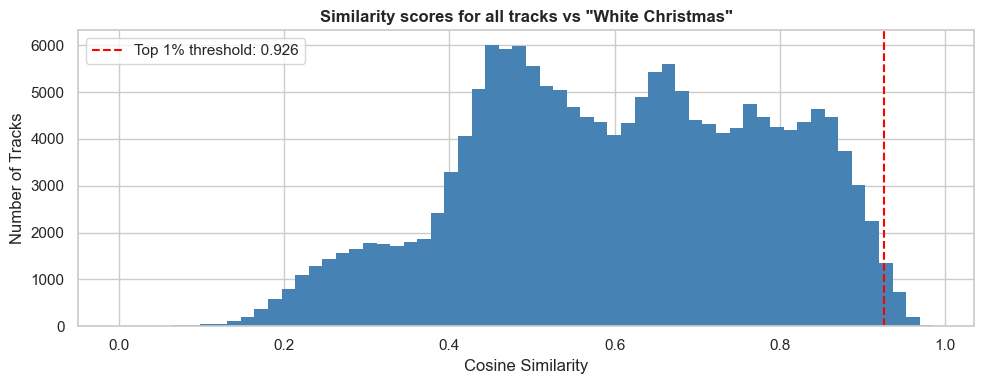

Mean similarity  : 0.6050
Top 10 recs are  : [0.9854 0.9813 0.9804 0.9804 0.9776 0.9771 0.9747 0.9747 0.9736 0.9734]


In [17]:
sample = 'White Christmas'
lower  = sample.lower()
match  = track_index[track_index['name'].str.lower() == lower]

if not match.empty:
    q_idx    = match.loc[match['popularity'].idxmax()].name
    q_vec    = feature_matrix[q_idx].reshape(1, -1)
    all_sims = cosine_similarity(q_vec, feature_matrix).flatten()
    all_sims = np.delete(all_sims, q_idx)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(all_sims, bins=60, color='steelblue', edgecolor='none')
    ax.axvline(np.percentile(all_sims, 99), color='red', linewidth=1.5, linestyle='--',
               label=f'Top 1% threshold: {np.percentile(all_sims, 99):.3f}')
    ax.set_title(f'Similarity scores for all tracks vs "{sample}"', fontweight='bold')
    ax.set_xlabel('Cosine Similarity')
    ax.set_ylabel('Number of Tracks')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f'Mean similarity  : {all_sims.mean():.4f}')
    print(f'Top 10 recs are  : {np.sort(all_sims)[-10:][::-1].round(4)}')

## 7. Save the Model

In [18]:
payload = {
    'feature_matrix' : feature_matrix,
    'track_index'    : track_index,
    'feature_columns': feature_columns,
}

with open(MODEL_DIR / 'recommender_payload.pkl', 'wb') as f:
    pickle.dump(payload, f)

print('Saved: models/recommender_payload.pkl')
print(f'  feature_matrix : {feature_matrix.shape}')
print(f'  track_index    : {track_index.shape}')

Saved: models/recommender_payload.pkl
  feature_matrix : (169040, 14)
  track_index    : (169040, 5)


## 8. Summary

### How It Works
1. Look up the query song in `track_index` to get its row number.
2. Retrieve the corresponding 14-dimensional vector from `feature_matrix`.
3. Compute cosine similarity against **all other tracks** (~170K dot products).
4. Return the top-N tracks with the highest scores.

### Optional Filters
- `exclude_same_artist=True` — avoids recommending the same artist repeatedly
- `year_range=(start, end)` — limits results to a specific era

### Known Limitations
- Content-only: ignores listening history or user preferences
- `popularity_norm` in the feature vector can bias results toward similarly-popular songs
- Very low catalog coverage — many songs cluster in tight audio regions

**src class used:** `ContentBasedRecommender` from `src.models.recommender`

**Next:** `06_evaluation.ipynb` — measure recommendation quality.